In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix)

# Importaciones de Imbalanced-Learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


--- INICIANDO ENTRENAMIENTO Y COMPARATIVA ---


Procesando modelos: 100%|██████████| 4/4 [1:43:24<00:00, 1551.16s/modelo, current_model=SVM (RBF Kernel)]



📂 Carpeta creada: Resultado_Datos
✅ CSV guardado en: Resultado_Datos\resultados_comparativa_modelos.csv

--- TABLA DE RESULTADOS ---
             Modelo  AUC Train  AUC Test  Accuracy  Precision  Recall  F1-Score
   SVM (RBF Kernel)     0.8692    0.8195    0.7777     0.5196  0.7075    0.5992
         Linear SVC     0.7832    0.7722    0.6752     0.3976  0.7425    0.5179
Logistic Regression     0.7836    0.7722    0.6842     0.4051  0.7351    0.5224
        Naive Bayes     0.7384    0.7261    0.6204     0.3541  0.7470    0.4804

📂 Carpeta de gráficos creada: Graficos\Graficos_Modelos

--- GENERANDO Y GUARDANDO GRÁFICOS ---
 Gráfico 1 guardado (JPG y PDF)


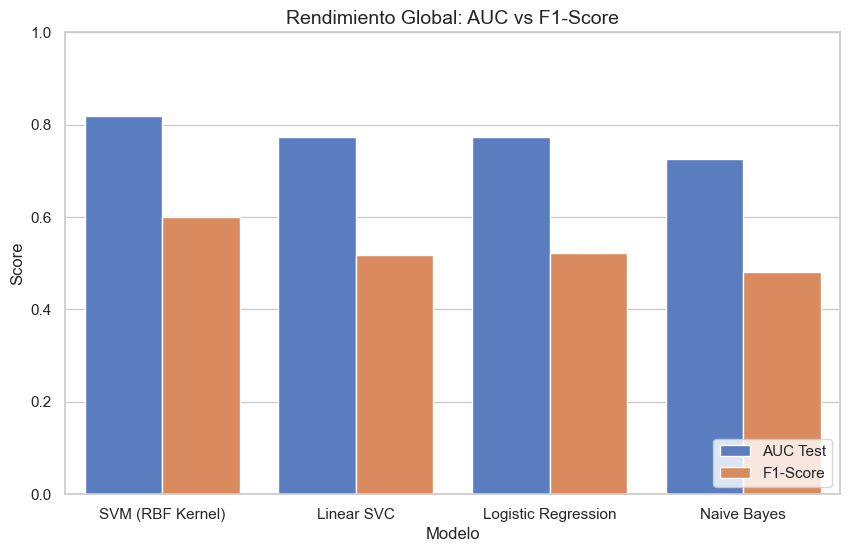

 Gráfico 2 guardado (JPG y PDF)


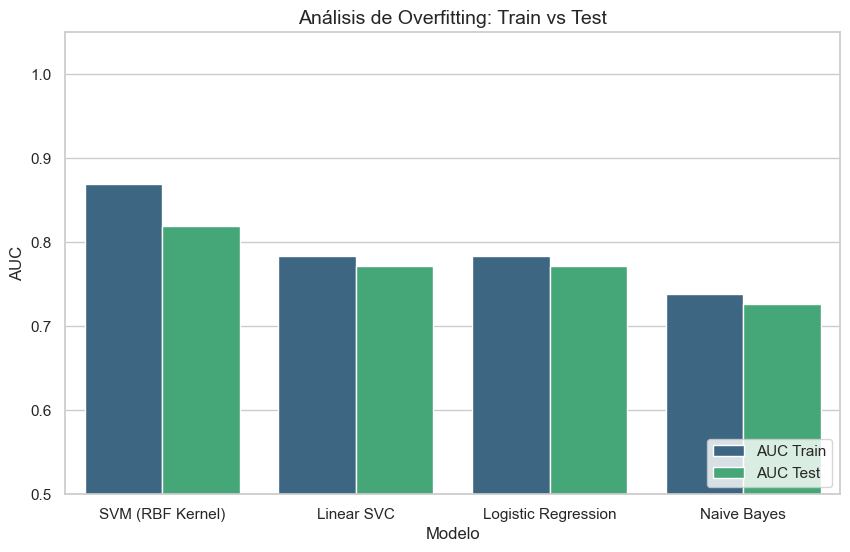

 Gráfico 3 guardado (JPG y PDF)


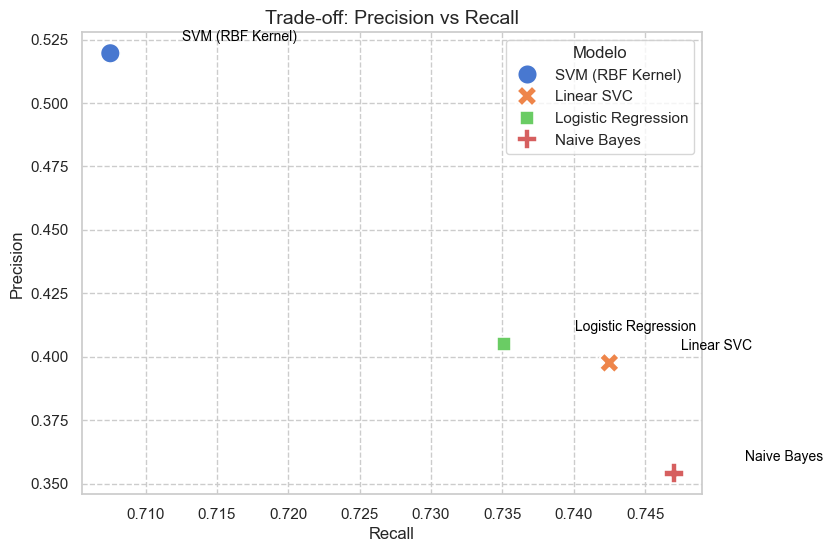


 PROCESO FINALIZADO. Archivos disponibles en las carpetas creadas.


In [2]:
sns.set(style="whitegrid", palette="mako")

if __name__ == "__main__":
    
    # ==========================================
    # 1. CARGA Y PREPROCESAMIENTO
    # ==========================================
    try:
        df = pd.read_csv('Datos/Transformados/df_meteorologico.csv')
    except FileNotFoundError:
        print("❌ Error: No se encuentra el archivo csv.")
        exit()

    drop_cols = [
        'Unnamed: 0', 'status', 'cancelled_at', 'cancellation_reason', 
        'cancellation_lead_time', 'days_before_cancel', 'days_before_checkin', 
        'completed_entry_forms_count', 'all_entry_forms_completed', 
        'last_entry_form_completed_at', 'checkout_time', 'checkin_time', 'booked_at',
        'travel_agency_name', 'requested_category_name', 'requested_category', 'asset',
        'asset_opening_date', 'idema_code', 'F_C_I', 'F_C_O', 'IDEMA'
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    numeric_features = [
        'lead_time', 'lenght_of_stay', 'adult_count', 'total_adr', 
        'IQR_hrMedia', 'IQR_tmed', 'product_count'
    ]
    categorical_features = ['origin', 'asset_type', 'rate_type', 'business_segment', 'recurrence']

    for col in categorical_features:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown').astype(str)
            
    for col in numeric_features:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    numeric_features = [c for c in numeric_features if c in df.columns]
    categorical_features = [c for c in categorical_features if c in df.columns]

    X = df[numeric_features + categorical_features]
    y = df['is_cancelled']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # ==========================================
    # 2. CONFIGURACIÓN DE MODELOS
    # ==========================================

    models_config = {
        "Naive Bayes": {
            "model": GaussianNB(),
            "params": {'classifier__var_smoothing': np.logspace(-9, -2, 3)}
        },
        "Logistic Regression": {
            "model": LogisticRegression(max_iter=1000, random_state=42),
            "params": {'classifier__C': [1, 10], 'classifier__solver': ['liblinear']}
        },
        "Linear SVC": {
            "model": CalibratedClassifierCV(LinearSVC(dual=False, random_state=42)),
            "params": {'classifier__estimator__C': [0.1, 1, 10]}
        },
        "SVM (RBF Kernel)": {
            "model": SVC(probability=True, random_state=42, cache_size=500),
            "params": {
                'classifier__C': [1, 10],  
                'classifier__gamma': ['scale'], 
                'classifier__kernel': ['rbf'] 
            }
        }
    }

    # ==========================================
    # 3. EJECUCIÓN (BUCLE PRINCIPAL)
    # ==========================================

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results = []
    
    print("\n--- INICIANDO ENTRENAMIENTO Y COMPARATIVA ---")
    iterator = tqdm(models_config.items(), desc="Procesando modelos", unit="modelo")

    for name, config in iterator:
        iterator.set_postfix(current_model=name)
        
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', config['model'])
        ])
        
        grid = GridSearchCV(pipeline, config['params'], cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        
        best_model = grid.best_estimator_
        
        y_train_prob = best_model.predict_proba(X_train)[:, 1]
        y_test_prob = best_model.predict_proba(X_test)[:, 1]
        y_test_pred = best_model.predict(X_test)
        
        results.append({
            "Modelo": name,
            "AUC Train": roc_auc_score(y_train, y_train_prob),
            "AUC Test": roc_auc_score(y_test, y_test_prob),
            "Accuracy": accuracy_score(y_test, y_test_pred),
            "Precision": precision_score(y_test, y_test_pred),
            "Recall": recall_score(y_test, y_test_pred),
            "F1-Score": f1_score(y_test, y_test_pred)
        })

    # ==========================================
    # 4. GUARDAR DATOS (CSV)
    # ==========================================

    df_results = pd.DataFrame(results)
    
    # Configuración Carpeta Datos
    folder_data = "Resultado_Datos"
    if not os.path.exists(folder_data):
        os.makedirs(folder_data)
        print(f"\n📂 Carpeta creada: {folder_data}")
        
    path_csv = os.path.join(folder_data, "resultados_comparativa_modelos.csv")
    df_results.to_csv(path_csv, index=False)
    print(f"✅ CSV guardado en: {path_csv}")
    
    df_results = df_results.sort_values(by="AUC Test", ascending=False)
    print("\n--- TABLA DE RESULTADOS ---")
    print(df_results.round(4).to_string(index=False))

    # ==========================================
    # 5. GENERACIÓN Y GUARDADO DE GRÁFICOS
    # ==========================================

    folder_imgs = os.path.join("Graficos", "Graficos_Modelos")
    
    if not os.path.exists(folder_imgs):
        os.makedirs(folder_imgs)
        print(f"\n📂 Carpeta de gráficos creada: {folder_imgs}")

    print("\n--- GENERANDO Y GUARDANDO GRÁFICOS ---")

    # GRÁFICO 1: Comparativa General
    df_melted = df_results.melt(id_vars="Modelo", value_vars=["AUC Test", "F1-Score"], var_name="Métrica", value_name="Score")
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="Modelo", y="Score", hue="Métrica")
    plt.title("Rendimiento Global: AUC vs F1-Score", fontsize=14)
    plt.ylim(0, 1.0)
    plt.legend(loc='lower right')
    
    plt.savefig(os.path.join(folder_imgs, "1_comparativa_general.jpg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(folder_imgs, "1_comparativa_general.pdf"), bbox_inches='tight')
    print(f" Gráfico 1 guardado (JPG y PDF)")
    plt.show()

    # GRÁFICO 2: Overfitting
    df_overfit = df_results.melt(id_vars="Modelo", value_vars=["AUC Train", "AUC Test"], var_name="Set", value_name="AUC")
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_overfit, x="Modelo", y="AUC", hue="Set", palette="viridis")
    plt.title("Análisis de Overfitting: Train vs Test", fontsize=14)
    plt.ylim(0.5, 1.05)
    plt.legend(loc='lower right')
    
    plt.savefig(os.path.join(folder_imgs, "2_analisis_overfitting.jpg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(folder_imgs, "2_analisis_overfitting.pdf"), bbox_inches='tight')
    print(f" Gráfico 2 guardado (JPG y PDF)")
    plt.show()

    # GRÁFICO 3: Precision vs Recall
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_results, x="Recall", y="Precision", hue="Modelo", style="Modelo", s=200)
    
    for i in range(df_results.shape[0]):
        plt.text(
            x=df_results.Recall.iloc[i]+0.005, 
            y=df_results.Precision.iloc[i]+0.005, 
            s=df_results.Modelo.iloc[i], 
            fontdict=dict(color='black', size=10)
        )
        
    plt.title("Trade-off: Precision vs Recall", fontsize=14)
    plt.grid(True, linestyle='--')
    
    plt.savefig(os.path.join(folder_imgs, "3_precision_recall.jpg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(folder_imgs, "3_precision_recall.pdf"), bbox_inches='tight')
    print(f" Gráfico 3 guardado (JPG y PDF)")
    plt.show()
    
    print(f"\n PROCESO FINALIZADO. Archivos disponibles en las carpetas creadas.")